In [86]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv('housingData.csv')

# Drop rows with missing values 
df.dropna(inplace=True)

In [88]:
# 1. Data Preprocessing

# Normalize numerical features
def normalize(df):
    return (df - df.mean()) / df.std()

X = df.drop('MEDV', axis=1)  # Target column is usually 'MEDV' in Boston Housing
y = df['MEDV']

X_normalized = normalize(X)

In [90]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

In [92]:
# 2. Linear Regression 
class LinearRegressionScratch:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.weights) + self.bias
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [94]:
# Evaluation Metrics
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2_score(y_true, y_pred):
    mean_y = np.mean(y_true)
    ss_tot = np.sum((y_true - mean_y) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_tot)

In [96]:
# Train and Evaluate Linear Regression
lr_model = LinearRegressionScratch()
lr_model.fit(X_train.values, y_train.values)
lr_preds = lr_model.predict(X_test.values)

lr_rmse = rmse(y_test.values, lr_preds)
lr_r2 = r2_score(y_test.values, lr_preds)

print(f"Linear Regression -> RMSE: {lr_rmse:.2f}, R²: {lr_r2:.2f}")

Linear Regression -> RMSE: 5.69, R²: 0.62


In [97]:
# 3. Random Forest 
from collections import Counter
import random

class DecisionTreeRegressor:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        data = np.concatenate((X, y.reshape(-1, 1)), axis=1)
        self.tree = self._build_tree(data)

    def _build_tree(self, data, depth=0):
        X, y = data[:, :-1], data[:, -1]
        n_samples, n_features = X.shape

        if depth >= self.max_depth or len(set(y)) == 1 or n_samples < self.min_samples_split:
            return np.mean(y)

        best_split = self._best_split(data, n_features)
        if not best_split:
            return np.mean(y)

        left, right = best_split["datasets"]
        return {
            "feature_idx": best_split["feature_idx"],
            "threshold": best_split["threshold"],
            "left": self._build_tree(left, depth + 1),
            "right": self._build_tree(right, depth + 1)
        }

    def _best_split(self, data, n_features):
        best_mse = float("inf")
        best_split = None
        for feature_idx in range(n_features):
            thresholds = np.unique(data[:, feature_idx])
            for threshold in thresholds:
                left = data[data[:, feature_idx] <= threshold]
                right = data[data[:, feature_idx] > threshold]
                if len(left) == 0 or len(right) == 0:
                    continue
                y_left, y_right = left[:, -1], right[:, -1]
                mse = self._mse(y_left, y_right)
                if mse < best_mse:
                    best_mse = mse
                    best_split = {
                        "feature_idx": feature_idx,
                        "threshold": threshold,
                        "datasets": (left, right)
                    }
        return best_split

    def _mse(self, y_left, y_right):
        left_mse = np.mean((y_left - np.mean(y_left)) ** 2)
        right_mse = np.mean((y_right - np.mean(y_right)) ** 2)
        return (len(y_left) * left_mse + len(y_right) * right_mse) / (len(y_left) + len(y_right))

    def _predict(self, inputs, tree):
        if not isinstance(tree, dict):
            return tree
        if inputs[tree["feature_idx"]] <= tree["threshold"]:
            return self._predict(inputs, tree["left"])
        else:
            return self._predict(inputs, tree["right"])

    def predict(self, X):
        return np.array([self._predict(x, self.tree) for x in X])

class RandomForestScratch:
    def __init__(self, n_trees=10, max_depth=10):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        for _ in range(self.n_trees):
            idxs = np.random.choice(len(X), len(X), replace=True)
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X[idxs], y[idxs])
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(tree_preds, axis=0)

In [98]:
# Train and Evaluate Random Forest
rf_model = RandomForestScratch(n_trees=10)
rf_model.fit(X_train.values, y_train.values)
rf_preds = rf_model.predict(X_test.values)

rf_rmse = rmse(y_test.values, rf_preds)
rf_r2 = r2_score(y_test.values, rf_preds)

print(f"Random Forest -> RMSE: {rf_rmse:.2f}, R²: {rf_r2:.2f}")

Random Forest -> RMSE: 5.48, R²: 0.64


In [101]:
# 4. XGBoost 


class XGBoostScratch:
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        y_pred = np.zeros(len(y))
        for _ in range(self.n_estimators):
            residuals = y - y_pred
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)
            update = tree.predict(X)
            y_pred += self.learning_rate * update
            self.trees.append(tree)

    def predict(self, X):
        y_pred = np.zeros(X.shape[0])
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred


In [102]:
# Train and Evaluate XGBoost
xgb_model = XGBoostScratch(n_estimators=20, learning_rate=0.1, max_depth=3)
xgb_model.fit(X_train.values, y_train.values)
xgb_preds = xgb_model.predict(X_test.values)

xgb_rmse = rmse(y_test.values, xgb_preds)
xgb_r2 = r2_score(y_test.values, xgb_preds)

print(f"XGBoost -> RMSE: {xgb_rmse:.2f}, R²: {xgb_r2:.2f}")

XGBoost -> RMSE: 6.61, R²: 0.48


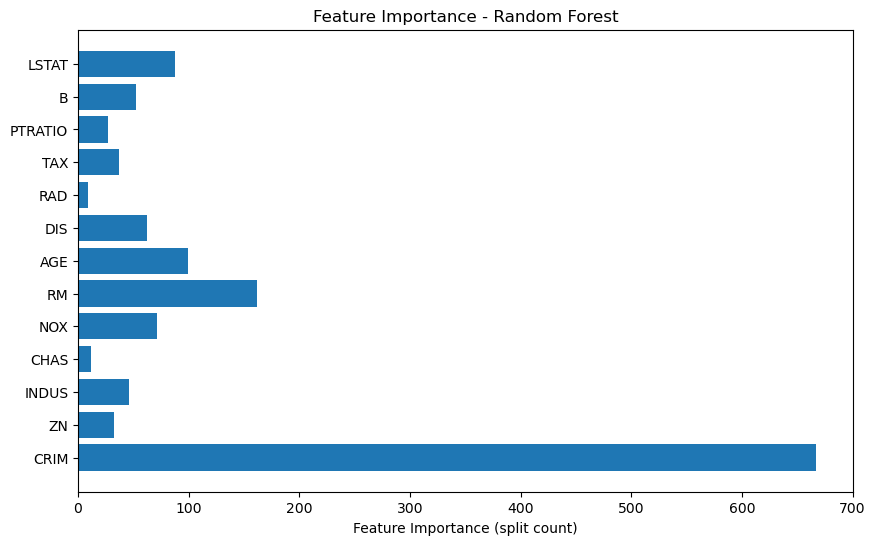

In [103]:
# 5. Feature Importance (Tree-based)

def compute_feature_importance(rf_model, feature_names):
    importance = np.zeros(len(feature_names))
    for tree in rf_model.trees:
        def count_splits(tree):
            if not isinstance(tree.tree, dict):
                return np.zeros(len(feature_names))
            stack = [tree.tree]
            local_importance = np.zeros(len(feature_names))
            while stack:
                node = stack.pop()
                if isinstance(node, dict):
                    idx = node['feature_idx']
                    local_importance[idx] += 1
                    stack.append(node['left'])
                    stack.append(node['right'])
            return local_importance
        importance += count_splits(tree)
    return importance

importance = compute_feature_importance(rf_model, X.columns)
plt.figure(figsize=(10, 6))
plt.barh(X.columns, importance)
plt.xlabel("Feature Importance (split count)")
plt.title("Feature Importance - Random Forest")
plt.show()